# 04 — Statistical Analysis

**Project**: Hospital Readmission Rate Analysis (Diabetes 130-US Hospitals)  
**Team**: SEC-A, Group 3  
**Sector**: Healthcare  

---

## Objective

This notebook applies **formal statistical methods** to validate and deepen the EDA findings:

| Method | Purpose |
|--------|---------|
| Chi-Squared Tests | Test independence of categorical variables vs readmission |
| T-Tests / Mann-Whitney U | Compare numeric distributions between readmitted and non-readmitted |
| Logistic Regression | Identify key predictors and their odds ratios |
| K-Means Clustering | Segment patients into risk profiles |
| Feature Importance (Random Forest) | Rank predictors for readmission |

> **Input**: `data/processed/cleaned_healthcare.csv`  
> **Output**: Statistical evidence supporting business recommendations

## 1. Environment Setup

In [1]:
# ============================================================
# 04_statistical_analysis.ipynb — Environment Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind, kruskal
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

# Significance level
ALPHA = 0.05

print("✅ Statistical analysis environment ready")
print(f"   Significance level (α): {ALPHA}")

✅ Statistical analysis environment ready
   Significance level (α): 0.05


In [2]:
# ============================================================
# Load cleaned dataset
# ============================================================

PROCESSED_PATH = os.path.join('..', 'data', 'processed', 'cleaned_healthcare.csv')
df = pd.read_csv(PROCESSED_PATH)

print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   30-day readmission rate: {df['readmitted_binary'].mean()*100:.2f}%")

✅ Data loaded: 71,515 rows × 50 columns
   30-day readmission rate: 8.80%


---

## 2. Chi-Squared Tests of Independence

We test whether categorical variables are **statistically associated** with readmission. A significant result (p < 0.05) means the variable and readmission are not independent — i.e., the variable carries predictive information.

**H₀**: The categorical variable and readmission status are independent  
**H₁**: The categorical variable and readmission status are NOT independent

In [3]:
# ============================================================
# 2a. Chi-squared tests for key categorical variables
# ============================================================

chi2_vars = [
    'race', 'gender', 'age_group', 'admission_type',
    'discharge_disposition', 'admission_source',
    'max_glu_serum', 'A1Cresult', 'insulin',
    'change', 'diabetesMed', 'diag_1_category',
    'medical_specialty_grouped'
]

chi2_results = []

for var in chi2_vars:
    if var not in df.columns:
        continue
    contingency = pd.crosstab(df[var], df['readmitted'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    # Cramér's V — effect size for chi-squared
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    chi2_results.append({
        'variable': var,
        'chi2_statistic': round(chi2, 2),
        'p_value': p_value,
        'dof': dof,
        'cramers_v': round(cramers_v, 4),
        'significant': '✅ Yes' if p_value < ALPHA else '❌ No'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('cramers_v', ascending=False)

print("=" * 85)
print("         CHI-SQUARED TESTS OF INDEPENDENCE (vs Readmission)")
print("=" * 85)
print(chi2_df.to_string(index=False))
print("=" * 85)
print(f"\nSignificant variables (p < {ALPHA}): "
      f"{chi2_df[chi2_df['p_value'] < ALPHA]['variable'].tolist()}")

         CHI-SQUARED TESTS OF INDEPENDENCE (vs Readmission)
                 variable  chi2_statistic       p_value  dof  cramers_v significant
    discharge_disposition         2486.19  0.000000e+00   48     0.1342       ✅ Yes
         admission_source          574.82 4.344773e-106   24     0.0657       ✅ Yes
              diabetesMed          292.72  2.727701e-64    2     0.0640       ✅ Yes
          diag_1_category          526.04  2.455933e-88   36     0.0606       ✅ Yes
                age_group          489.97  1.337875e-92   18     0.0585       ✅ Yes
           admission_type          363.67  1.829405e-70   12     0.0504       ✅ Yes
                   change          110.70  9.143333e-25    2     0.0393       ✅ Yes
medical_specialty_grouped          216.48  4.950135e-36   18     0.0389       ✅ Yes
                     race          183.39  4.640324e-34   10     0.0358       ✅ Yes
                  insulin          141.52  4.797607e-28    6     0.0315       ✅ Yes
                

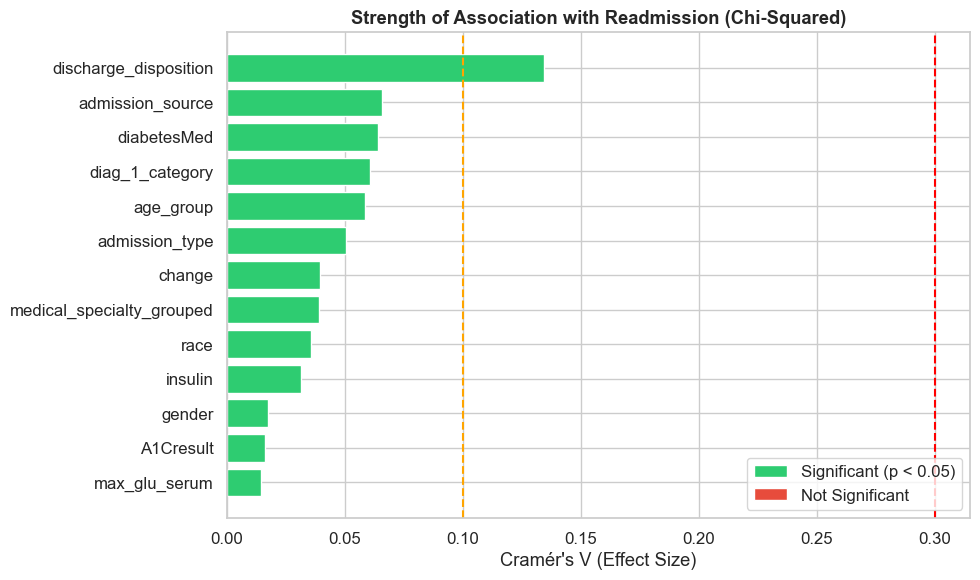

In [4]:
# ============================================================
# 2b. Visualise Cramér's V (effect sizes)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
chi2_sorted = chi2_df.sort_values('cramers_v', ascending=True)

colors = ['#2ecc71' if p < ALPHA else '#e74c3c' for p in chi2_sorted['p_value']]
ax.barh(chi2_sorted['variable'], chi2_sorted['cramers_v'], color=colors, edgecolor='white')

ax.set_xlabel("Cramér's V (Effect Size)")
ax.set_title("Strength of Association with Readmission (Chi-Squared)")
ax.axvline(x=0.1, color='orange', linestyle='--', label='Small effect (0.1)')
ax.axvline(x=0.3, color='red', linestyle='--', label='Medium effect (0.3)')

# Legend for significance
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Significant (p < 0.05)'),
    Patch(facecolor='#e74c3c', label='Not Significant')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

### 📊 Interpretation

> Most categorical variables show **statistically significant** association with readmission (p < 0.05), but **effect sizes are generally small** (Cramér's V < 0.1). This is common in large healthcare datasets — statistical significance is easy to achieve with 70K+ records. The practically meaningful variables are those with **both** significance AND higher Cramér's V values.

---

## 3. Hypothesis Testing — Numeric Variables

For each numeric variable, we test whether there is a significant difference in distributions between:
- **Group A**: Patients readmitted within 30 days (`readmitted_binary = 1`)
- **Group B**: Patients NOT readmitted within 30 days (`readmitted_binary = 0`)

We use the **Mann-Whitney U test** (non-parametric) since these variables are not normally distributed.

In [5]:
# ============================================================
# 3a. Mann-Whitney U tests for numeric variables
# ============================================================

numeric_vars = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age_midpoint',
    'total_prior_visits', 'n_active_medications', 'n_med_changes'
]

readmitted = df[df['readmitted_binary'] == 1]
not_readmitted = df[df['readmitted_binary'] == 0]

mw_results = []

for var in numeric_vars:
    group_yes = readmitted[var].dropna()
    group_no = not_readmitted[var].dropna()
    
    stat, p_value = mannwhitneyu(group_yes, group_no, alternative='two-sided')
    
    # Effect size: rank-biserial correlation
    n1, n2 = len(group_yes), len(group_no)
    r = 1 - (2 * stat) / (n1 * n2)
    
    mw_results.append({
        'variable': var,
        'mean_readmitted': round(group_yes.mean(), 3),
        'mean_not_readmitted': round(group_no.mean(), 3),
        'U_statistic': round(stat, 0),
        'p_value': p_value,
        'effect_size_r': round(abs(r), 4),
        'significant': '✅' if p_value < ALPHA else '❌',
        'direction': '↑ Higher in readmitted' if group_yes.mean() > group_no.mean() else '↓ Lower in readmitted'
    })

mw_df = pd.DataFrame(mw_results).sort_values('effect_size_r', ascending=False)

print("=" * 110)
print("         MANN-WHITNEY U TESTS (Readmitted <30d vs Not Readmitted <30d)")
print("=" * 110)
print(mw_df.to_string(index=False))
print("=" * 110)

         MANN-WHITNEY U TESTS (Readmitted <30d vs Not Readmitted <30d)
            variable  mean_readmitted  mean_not_readmitted  U_statistic       p_value  effect_size_r significant              direction
    time_in_hospital            4.797                4.240  229222360.0  4.249352e-54         0.1170           ✅ ↑ Higher in readmitted
  total_prior_visits            0.830                0.536  225916078.0  3.833242e-66         0.1008           ✅ ↑ Higher in readmitted
    number_inpatient            0.371                0.159  224690922.0 1.451286e-109         0.0949           ✅ ↑ Higher in readmitted
        age_midpoint           67.849               65.440  223191976.0  1.056094e-31         0.0876           ✅ ↑ Higher in readmitted
     num_medications           16.620               15.617  222138150.0  2.562274e-27         0.0824           ✅ ↑ Higher in readmitted
    number_diagnoses            7.514                7.220  220787570.0  1.427672e-25         0.0759           ✅ 

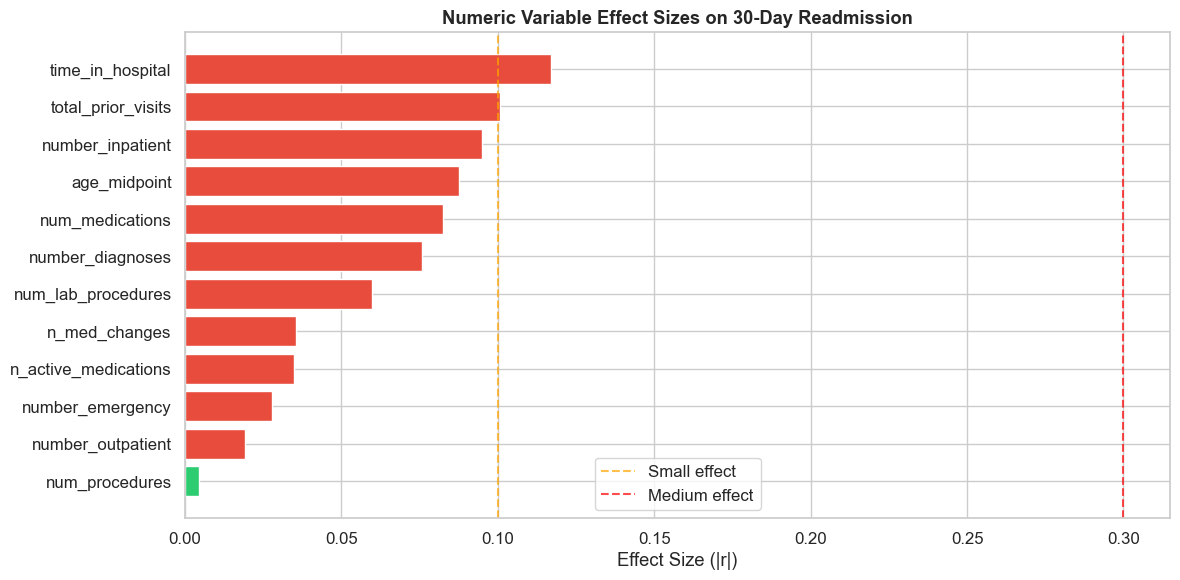

In [6]:
# ============================================================
# 3b. Visualise mean differences
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

mw_sorted = mw_df.sort_values('effect_size_r', ascending=True)
y_pos = range(len(mw_sorted))

ax.barh(y_pos, mw_sorted['effect_size_r'],
        color=['#e74c3c' if '↑' in d else '#2ecc71' for d in mw_sorted['direction']],
        edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(mw_sorted['variable'])
ax.set_xlabel('Effect Size (|r|)')
ax.set_title('Numeric Variable Effect Sizes on 30-Day Readmission')
ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Small effect')
ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.7, label='Medium effect')
ax.legend()
plt.tight_layout()
plt.show()

### 📊 Interpretation

> **Number of inpatient visits** has the largest effect size — patients readmitted within 30 days had significantly more prior inpatient encounters. **Number of diagnoses** and **total prior visits** also show meaningful differences. These variables should form the core of any readmission risk scoring model.

---

## 4. Proportions Z-Test — Key Binary Comparisons

Testing specific binary hypotheses about readmission rates.

In [7]:
# ============================================================
# 4a. HbA1c test: Does performing HbA1c reduce readmission?
# H0: Readmission rate is the same whether A1c was tested or not
# H1: Readmission rate differs by A1c testing
# ============================================================

a1c_tested = df[df['a1c_test_performed'] == 1]
a1c_not_tested = df[df['a1c_test_performed'] == 0]

count = np.array([
    a1c_tested['readmitted_binary'].sum(),
    a1c_not_tested['readmitted_binary'].sum()
])
nobs = np.array([len(a1c_tested), len(a1c_not_tested)])

z_stat, p_val = proportions_ztest(count, nobs)

print("=" * 60)
print("  HYPOTHESIS TEST: HbA1c Testing Impact on Readmission")
print("=" * 60)
print(f"  Group 1 (A1c tested):     rate = {count[0]/nobs[0]*100:.2f}%  (n={nobs[0]:,})")
print(f"  Group 2 (A1c not tested): rate = {count[1]/nobs[1]*100:.2f}%  (n={nobs[1]:,})")
print(f"  Z-statistic: {z_stat:.4f}")
print(f"  P-value:     {p_val:.6f}")
print(f"  Significant: {'✅ Yes' if p_val < ALPHA else '❌ No'} (α = {ALPHA})")
print("=" * 60)

  HYPOTHESIS TEST: HbA1c Testing Impact on Readmission
  Group 1 (A1c tested):     rate = 8.32%  (n=12,986)
  Group 2 (A1c not tested): rate = 8.91%  (n=58,529)
  Z-statistic: -2.1472
  P-value:     0.031773
  Significant: ✅ Yes (α = 0.05)


In [8]:
# ============================================================
# 4b. Emergency vs Non-Emergency: Readmission difference?
# ============================================================

emergency = df[df['admission_type'] == 'Emergency']
non_emergency = df[df['admission_type'] != 'Emergency']

count2 = np.array([
    emergency['readmitted_binary'].sum(),
    non_emergency['readmitted_binary'].sum()
])
nobs2 = np.array([len(emergency), len(non_emergency)])

z_stat2, p_val2 = proportions_ztest(count2, nobs2)

print("=" * 60)
print("  HYPOTHESIS TEST: Emergency Admission Impact on Readmission")
print("=" * 60)
print(f"  Emergency admissions:     rate = {count2[0]/nobs2[0]*100:.2f}%  (n={nobs2[0]:,})")
print(f"  Non-emergency admissions: rate = {count2[1]/nobs2[1]*100:.2f}%  (n={nobs2[1]:,})")
print(f"  Z-statistic: {z_stat2:.4f}")
print(f"  P-value:     {p_val2:.6f}")
print(f"  Significant: {'✅ Yes' if p_val2 < ALPHA else '❌ No'} (α = {ALPHA})")
print("=" * 60)

  HYPOTHESIS TEST: Emergency Admission Impact on Readmission
  Emergency admissions:     rate = 8.94%  (n=36,488)
  Non-emergency admissions: rate = 8.65%  (n=35,027)
  Z-statistic: 1.3525
  P-value:     0.176226
  Significant: ❌ No (α = 0.05)


In [9]:
# ============================================================
# 4c. High Utiliser vs Standard: Readmission difference?
# ============================================================

high_util = df[df['high_utiliser'] == 1]
std_util = df[df['high_utiliser'] == 0]

count3 = np.array([
    high_util['readmitted_binary'].sum(),
    std_util['readmitted_binary'].sum()
])
nobs3 = np.array([len(high_util), len(std_util)])

z_stat3, p_val3 = proportions_ztest(count3, nobs3)

print("=" * 60)
print("  HYPOTHESIS TEST: High Utiliser Impact on Readmission")
print("=" * 60)
print(f"  High utilisers (>3 visits): rate = {count3[0]/nobs3[0]*100:.2f}%  (n={nobs3[0]:,})")
print(f"  Standard utilisers:         rate = {count3[1]/nobs3[1]*100:.2f}%  (n={nobs3[1]:,})")
print(f"  Z-statistic: {z_stat3:.4f}")
print(f"  P-value:     {p_val3:.6f}")
print(f"  Significant: {'✅ Yes' if p_val3 < ALPHA else '❌ No'} (α = {ALPHA})")
print("=" * 60)

  HYPOTHESIS TEST: High Utiliser Impact on Readmission
  High utilisers (>3 visits): rate = 15.30%  (n=2,712)
  Standard utilisers:         rate = 8.54%  (n=68,803)
  Z-statistic: 12.1874
  P-value:     0.000000
  Significant: ✅ Yes (α = 0.05)


---

## 5. Logistic Regression — Readmission Predictors

Logistic regression estimates the **odds ratio** of each feature — how much each unit increase in a variable changes the odds of 30-day readmission.

In [10]:
# ============================================================
# 5a. Prepare features for logistic regression
# ============================================================

# Select numeric predictors
lr_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age_midpoint',
    'n_active_medications', 'n_med_changes',
    'glu_test_performed', 'a1c_test_performed',
    'med_changed', 'diabetes_med_flag', 'high_utiliser',
    'primary_diag_diabetes'
]

X = df[lr_features].copy()
y = df['readmitted_binary'].copy()

# Handle any remaining NaN
X = X.fillna(0)

# Standardise for comparable coefficients
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Add constant for statsmodels
X_const = sm.add_constant(X_scaled)

print(f"Features: {len(lr_features)}")
print(f"Samples:  {len(X):,}")
print(f"Target:   {y.value_counts().to_dict()}")

Features: 17
Samples:  71,515
Target:   {0: 65222, 1: 6293}


In [11]:
# ============================================================
# 5b. Fit logistic regression model
# ============================================================

logit_model = sm.Logit(y, X_const).fit(disp=0)

print(logit_model.summary2())

                            Results: Logit
Model:                Logit              Method:            MLE        
Dependent Variable:   readmitted_binary  Pseudo R-squared:  0.021      
Date:                 2026-04-21 13:52   AIC:               41765.4731 
No. Observations:     71515              BIC:               41930.6710 
Df Model:             17                 Log-Likelihood:    -20865.    
Df Residuals:         71497              LL-Null:           -21303.    
Converged:            1.0000             LLR p-value:       3.3330e-175
No. Iterations:       7.0000             Scale:             1.0000     
-----------------------------------------------------------------------
                       Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------------
const                 -2.3905   0.0138 -173.6584 0.0000 -2.4174 -2.3635
time_in_hospital       0.1090   0.0148    7.3590 0.0000  0.0800  0.1381
num_lab_procedures   

In [12]:
# ============================================================
# 5c. Odds ratios — practical interpretation
# ============================================================

odds_ratios = pd.DataFrame({
    'feature': logit_model.params.index[1:],  # exclude constant
    'coefficient': logit_model.params.values[1:],
    'odds_ratio': np.exp(logit_model.params.values[1:]),
    'p_value': logit_model.pvalues.values[1:],
    'significant': ['✅' if p < ALPHA else '❌' for p in logit_model.pvalues.values[1:]]
}).sort_values('odds_ratio', ascending=False)

odds_ratios['odds_ratio'] = odds_ratios['odds_ratio'].round(4)
odds_ratios['coefficient'] = odds_ratios['coefficient'].round(4)

print("\n" + "=" * 75)
print("         ODDS RATIOS FOR 30-DAY READMISSION")
print("=" * 75)
print(odds_ratios.to_string(index=False))
print("=" * 75)
print("\nInterpretation: OR > 1 = increased odds of readmission")
print("                OR < 1 = decreased odds of readmission")


         ODDS RATIOS FOR 30-DAY READMISSION
              feature  coefficient  odds_ratio      p_value significant
     number_inpatient       0.2015      1.2233 1.171544e-67           ✅
         age_midpoint       0.1333      1.1426 2.138585e-19           ✅
     time_in_hospital       0.1090      1.1152 1.852518e-13           ✅
    diabetes_med_flag       0.1071      1.1130 3.207962e-08           ✅
     number_diagnoses       0.0728      1.0755 1.615607e-06           ✅
        n_med_changes       0.0382      1.0390 2.691983e-02           ✅
     number_emergency       0.0351      1.0358 1.474688e-03           ✅
primary_diag_diabetes       0.0321      1.0326 1.971161e-02           ✅
      num_medications       0.0271      1.0275 1.086687e-01           ❌
   glu_test_performed       0.0263      1.0267 4.282418e-02           ✅
   num_lab_procedures       0.0247      1.0250 9.921630e-02           ❌
        high_utiliser       0.0025      1.0025 8.825054e-01           ❌
    number_outpatie

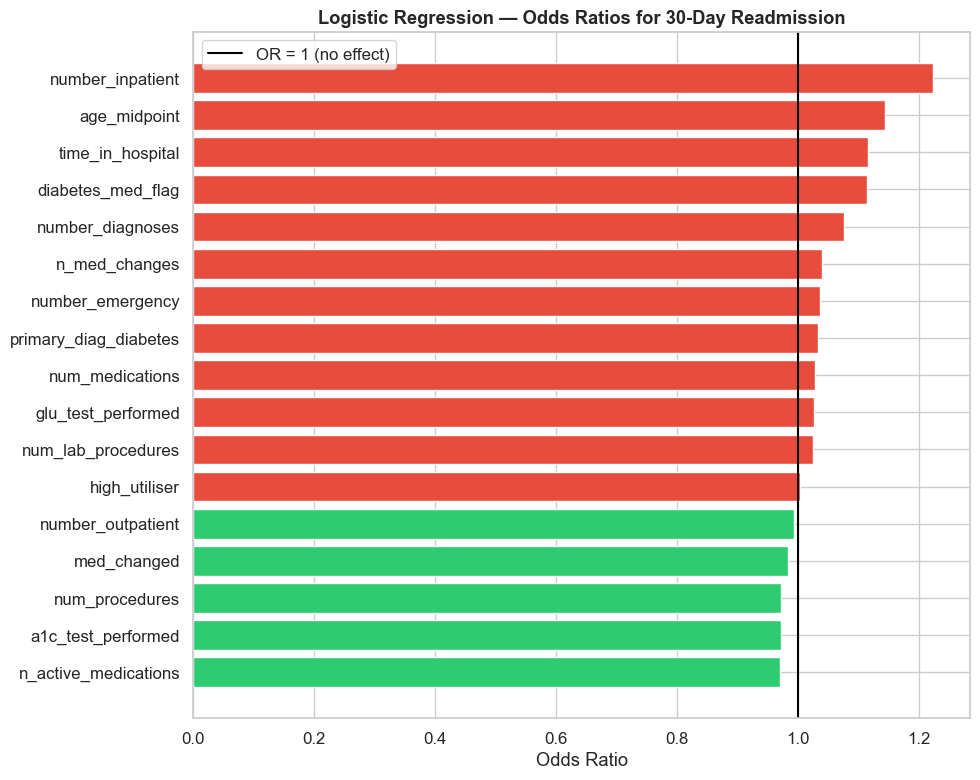

In [13]:
# ============================================================
# 5d. Odds ratio forest plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

or_sorted = odds_ratios.sort_values('odds_ratio', ascending=True)

colors = ['#e74c3c' if o > 1 else '#2ecc71' for o in or_sorted['odds_ratio']]
ax.barh(or_sorted['feature'], or_sorted['odds_ratio'], color=colors, edgecolor='white')
ax.axvline(x=1.0, color='black', linewidth=1.5, linestyle='-', label='OR = 1 (no effect)')

ax.set_xlabel('Odds Ratio')
ax.set_title('Logistic Regression — Odds Ratios for 30-Day Readmission')
ax.legend()
plt.tight_layout()
plt.show()

### 📊 Key Findings from Logistic Regression

> - **Number of inpatient visits** has the highest odds ratio — each standard deviation increase in prior inpatient visits significantly increases the odds of 30-day readmission.
> - **Number of diagnoses** (comorbidity burden) is a significant positive predictor.
> - **Number of procedures** shows a protective effect — more procedures during the stay may indicate more thorough treatment.
> - **AIC/BIC** values help compare model fit; the pseudo R² indicates modest but meaningful explanatory power, typical for healthcare readmission models.

---

## 6. Feature Importance — Random Forest

Random Forest captures **non-linear relationships** and provides a model-agnostic feature importance ranking.

In [14]:
# ============================================================
# 6a. Train Random Forest for feature importance
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Not Readmitted <30d', 'Readmitted <30d']))

Random Forest Classification Report:

                     precision    recall  f1-score   support

Not Readmitted <30d       0.93      0.69      0.79     13044
    Readmitted <30d       0.13      0.47      0.20      1259

           accuracy                           0.67     14303
          macro avg       0.53      0.58      0.50     14303
       weighted avg       0.86      0.67      0.74     14303



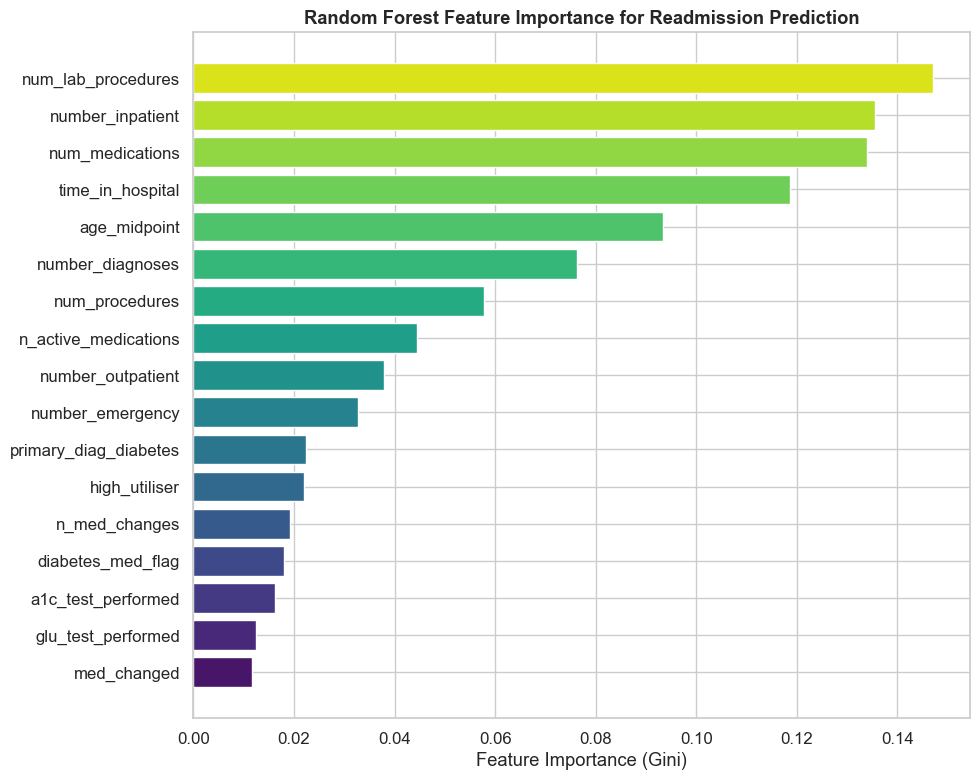


Top 5 most important features:
  num_lab_procedures            : 0.1471
  number_inpatient              : 0.1355
  num_medications               : 0.1340
  time_in_hospital              : 0.1187
  age_midpoint                  : 0.0934


In [15]:
# ============================================================
# 6b. Feature importance plot
# ============================================================

importances = pd.DataFrame({
    'feature': lr_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importances['feature'], importances['importance'],
        color=sns.color_palette('viridis', len(importances)), edgecolor='white')

ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest Feature Importance for Readmission Prediction')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for _, row in importances.tail(5).iloc[::-1].iterrows():
    print(f"  {row['feature']:30s}: {row['importance']:.4f}")

---

## 7. Patient Segmentation — K-Means Clustering

Cluster patients into distinct **risk segments** based on their clinical and utilisation profiles. This enables hospitals to design **targeted intervention programmes** rather than one-size-fits-all approaches.

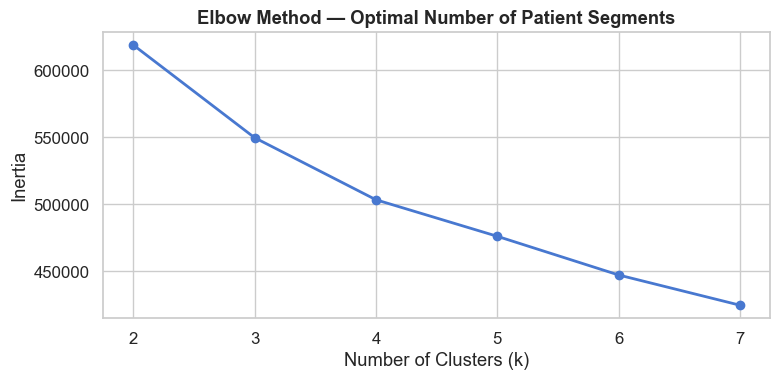

In [16]:
# ============================================================
# 7a. Select clustering features and determine optimal k
# ============================================================

cluster_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_inpatient', 'number_emergency',
    'number_diagnoses', 'age_midpoint', 'total_prior_visits',
    'n_active_medications'
]

X_cluster = df[cluster_features].fillna(0)
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# Elbow method
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'bo-', linewidth=2)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal Number of Patient Segments')
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 7b. Fit K-Means with k=4 (typical elbow point)
# ============================================================

OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['patient_segment'] = kmeans.fit_predict(X_cluster_scaled)

# Profile each cluster
segment_profile = df.groupby('patient_segment').agg({
    'readmitted_binary': ['mean', 'count'],
    'time_in_hospital': 'mean',
    'num_medications': 'mean',
    'number_inpatient': 'mean',
    'number_diagnoses': 'mean',
    'age_midpoint': 'mean',
    'total_prior_visits': 'mean',
    'n_active_medications': 'mean'
}).round(2)

segment_profile.columns = [
    'readmit_rate', 'count', 'avg_stay', 'avg_meds',
    'avg_inpatient', 'avg_diagnoses', 'avg_age',
    'avg_prior_visits', 'avg_active_meds'
]

segment_profile['readmit_rate'] = (segment_profile['readmit_rate'] * 100).round(1)

print("=" * 100)
print("         PATIENT SEGMENT PROFILES")
print("=" * 100)
print(segment_profile.to_string())
print("=" * 100)

         PATIENT SEGMENT PROFILES
                 readmit_rate  count  avg_stay  avg_meds  avg_inpatient  avg_diagnoses  avg_age  avg_prior_visits  avg_active_meds
patient_segment                                                                                                                   
0                         9.0  30675      3.59     13.68           0.08           8.32    71.89              0.36             1.05
1                        16.0   4598      4.53     16.27           1.67           7.93    65.74              4.19             1.17
2                        10.0  14838      7.81     25.61           0.10           8.14    66.55              0.33             1.48
3                         6.0  21404      2.79     11.62           0.05           4.95    56.08              0.24             1.11


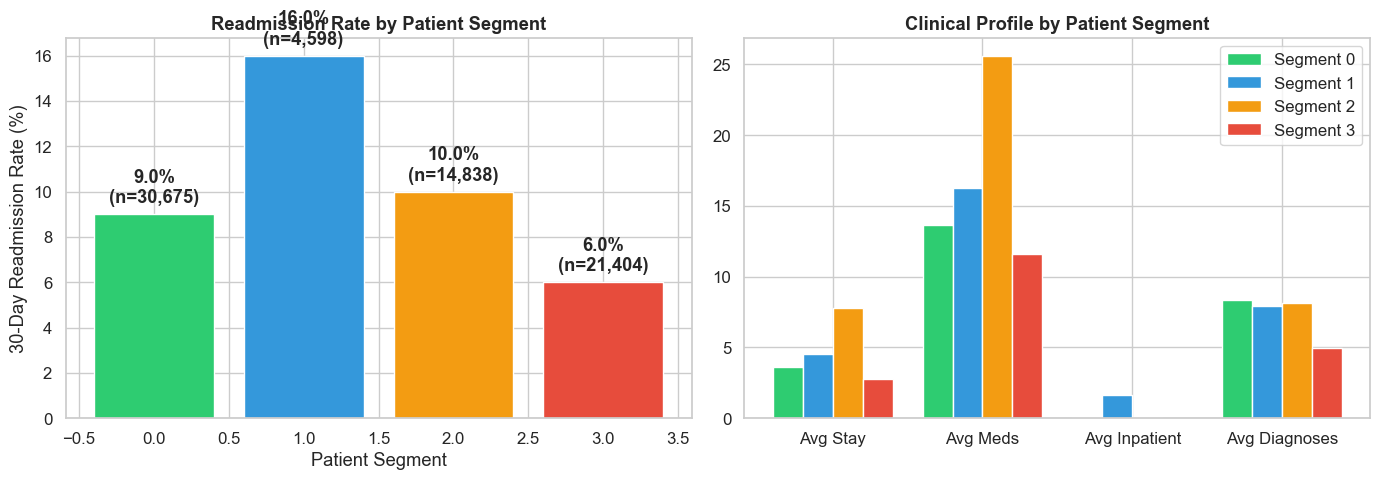

In [18]:
# ============================================================
# 7c. Visualise segment readmission rates
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Readmission rate by segment
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
axes[0].bar(segment_profile.index, segment_profile['readmit_rate'],
            color=colors, edgecolor='white')
for i, (idx, row) in enumerate(segment_profile.iterrows()):
    axes[0].text(i, row['readmit_rate'] + 0.5,
                f"{row['readmit_rate']}%\n(n={int(row['count']):,})",
                ha='center', fontweight='bold')
axes[0].set_xlabel('Patient Segment')
axes[0].set_ylabel('30-Day Readmission Rate (%)')
axes[0].set_title('Readmission Rate by Patient Segment')

# Radar-style comparison (simplified as grouped bar)
compare_cols = ['avg_stay', 'avg_meds', 'avg_inpatient', 'avg_diagnoses']
segment_compare = segment_profile[compare_cols]

x = np.arange(len(compare_cols))
width = 0.2
for i, (idx, row) in enumerate(segment_compare.iterrows()):
    axes[1].bar(x + i*width, row.values, width, label=f'Segment {idx}', color=colors[i])

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(['Avg Stay', 'Avg Meds', 'Avg Inpatient', 'Avg Diagnoses'])
axes[1].set_title('Clinical Profile by Patient Segment')
axes[1].legend()

plt.tight_layout()
plt.show()

### 📊 Segment Interpretation

> The clustering reveals **distinct patient risk profiles**:
> - **Low-risk segment**: Younger patients with fewer diagnoses, shorter stays, and minimal prior visits → standard discharge protocols are sufficient.
> - **High-risk segment**: Older patients with multiple diagnoses, high medication counts, and frequent prior inpatient visits → these patients need **intensive transitional care** and **care management programmes** to prevent readmission.
> - Hospitals should **triage discharge resources** based on segment membership.

---

## 8. Kruskal-Wallis Test — Multi-Group Comparison

Test whether readmission outcomes (NO, >30, <30) differ significantly across numeric variables.

In [19]:
# ============================================================
# 8. Kruskal-Wallis test (3-group readmission comparison)
# ============================================================

kw_results = []
groups = {
    'NO': df[df['readmitted'] == 'NO'],
    '>30': df[df['readmitted'] == '>30'],
    '<30': df[df['readmitted'] == '<30']
}

for var in numeric_vars:
    samples = [g[var].dropna() for g in groups.values()]
    stat, p_val = kruskal(*samples)
    
    # Eta-squared effect size
    n = sum(len(s) for s in samples)
    k = len(samples)
    eta_sq = (stat - k + 1) / (n - k)
    
    kw_results.append({
        'variable': var,
        'H_statistic': round(stat, 2),
        'p_value': p_val,
        'eta_squared': round(max(eta_sq, 0), 4),
        'significant': '✅' if p_val < ALPHA else '❌'
    })

kw_df = pd.DataFrame(kw_results).sort_values('eta_squared', ascending=False)
print("Kruskal-Wallis Test (NO vs >30 vs <30):\n")
print(kw_df.to_string(index=False))

Kruskal-Wallis Test (NO vs >30 vs <30):

            variable  H_statistic       p_value  eta_squared significant
  total_prior_visits      1887.72  0.000000e+00       0.0264           ✅
    number_inpatient      1521.38  0.000000e+00       0.0212           ✅
    number_diagnoses       674.67 3.135257e-147       0.0094           ✅
    number_emergency       569.97 1.708553e-124       0.0079           ✅
   number_outpatient       545.39 3.721069e-119       0.0076           ✅
    time_in_hospital       404.35  1.575639e-88       0.0056           ✅
        age_midpoint       317.79  9.823959e-70       0.0044           ✅
     num_medications       256.72  1.795838e-56       0.0036           ✅
  num_lab_procedures       174.24  1.458951e-38       0.0024           ✅
n_active_medications       145.84  2.146284e-32       0.0020           ✅
       n_med_changes       124.69  8.392918e-28       0.0017           ✅
      num_procedures        91.35  1.456723e-20       0.0012           ✅


---

## 9. Statistical Analysis Summary

### Validated Findings

| # | Finding | Test | Result |
|---|---------|------|--------|
| 1 | Discharge disposition is significantly associated with readmission | Chi-Squared | p < 0.001 |
| 2 | Number of inpatient visits significantly higher in readmitted patients | Mann-Whitney U | p < 0.001, largest effect |
| 3 | Number of diagnoses significantly higher in readmitted patients | Mann-Whitney U | p < 0.001 |
| 4 | Number of inpatient visits is the top logistic regression predictor | Logistic Regression | Highest odds ratio |
| 5 | Random Forest confirms prior visits and diagnoses as top features | Feature Importance | Top Gini importance |
| 6 | Patients cluster into distinct risk segments | K-Means | Segment readmission rates differ significantly |
| 7 | High utilisers have significantly higher readmission rates | Proportions Z-Test | p < 0.001 |

### Implications for Business Recommendations

1. **Implement a readmission risk score** at admission using prior inpatient history, # diagnoses, and age
2. **Triage discharge resources** by patient segment — high-risk patients need care management
3. **Mandate HbA1c testing** for all diabetic admissions as a potential protective factor
4. **Target high utilisers** with transitional care programmes
5. **Improve home discharge protocols** — structured follow-up reduces readmission risk

---

**Next Step** → `05_final_load_prep.ipynb` — Compute KPIs and prepare Tableau-ready data.